# ACT DR6 lensing × DETG：point-to-point validation 與 Fisher 檢查

對象：`act_lens.py` 中的 `ACTDR6LensDETG`（以 `act_dr6_lenslike.ACTDR6LensLike` 為基底，對 $C_L^{\kappa\kappa}$ 乘上 $r(L)=C_L^{\kappa\kappa}[\mathrm{DETG}]/C_L^{\kappa\kappa}[\Lambda\mathrm{CDM}]$）。

| 部分 | 目的 | 判準 |
|---|---|---|
| **A. Point-to-point validation** | 沒有 DETG 效應時，與官方 `ACTDR6LensLike` 逐點相同；所有 likelihood 修正（norm / N1 / Planck / act_calib / Alens）都沒有被漏掉 | 逐 $L$、逐 bin、$\ln\mathcal{L}$ 比對 |
| **B. 效應與 Fisher** | 看 $\beta$ 對 $C_L^{\kappa\kappa}$ 的效應、參數間簡併、Fisher 是否可信 | $\sigma_\beta$、相關係數、簡併倍率、沿簡併方向的 exact $\Delta\chi^2$ vs Fisher |
| **C. 結論** | 判斷是否需要跑 MCMC | 自動列出各項判準 |

**作法重點**
- 官方 likelihood（`ref`）和受測版本放在**同一個 cobaya model** 裡，共用同一次 CAMB 結果，所以比對不受 CAMB 數值雜訊影響，差異只來自 likelihood 程式本身。
- 攔截 `generic_lnlike`（只是包一層，回傳值不變），取出每個 likelihood 實際送進去的 $C_L^{\kappa\kappa}$、CMB 頻譜、修正選項，以及 binned theory vector。
- **A4 專門測 sampler 實際的情況**（cobaya 的 cache 開著、只改 $A_s$ 或 $n_s$ 時 CAMB 會重用 transfer function）。這一項在目前的 `act_lens.py` 會失敗，原因與修法寫在 A4。

**執行模式**
- `DATA_MODE="real"`：使用 ACT DR6 lensing v1.2 資料（正式結果用這個）。
- `DATA_MODE="mock"`：自動產生同樣檔案結構的合成資料（bin edges 與 ACT 相同、誤差約對應 S/N≈43），只用來確認程式路徑能跑通；**mock 的 Fisher 數字不可當作結果**。

在 `FAST=True` 時全部跑完約 15–25 分鐘（2 核心）；`FAST=False`（ACT 建議的 CAMB 精度）會更久。

## 0. 設定

In [1]:
# ===================== 使用者設定 =====================
DATA_MODE    = "mock"          # "real" | "mock"
DDIR         = "/path/to/ACT_dr6_likelihood/v1.2"   # real 模式：解壓後的 v1.2 資料夾
ACT_LENS_DIR = "."             # act_lens.py 與 growth_model.py 所在資料夾
WORK_DIR     = "./detg_validation_work"

FAST         = True            # True：CAMB 低精度（快速檢查）；False：ACT 建議精度
P_LIST       = [1, 3, 5]       # 要檢查的 DETG p
BETA_TEST    = 0.3             # A2：beta != 0 時的 plumbing 檢查
N_POINTS     = 4               # A1：除了 fiducial 以外，再抽幾個隨機參數點
SEED         = 1234
MASS_SPLIT   = "single"        # CCL 的中微子分配；cobaya CAMB 預設只有 1 顆有質量中微子，用 "single" 讓 CCL 背景與 CAMB P(k) 一致

# Fisher 設定
FISHER_VARIANT = "act_baseline"        # 與正式分析相同的 variant
BETA_FID       = 0.0                   # Fisher fiducial 的 beta
GAUSS_PRIORS   = {"ombh2": 0.0005, "ns": 0.02}   # ACT lensing-only 分析的 Gaussian prior 寬度（請對照原文）
FLAT_PRIORS    = {"beta_detg": (-1.0, 1.0), "H0": (40., 100.), "logA": (2.0, 4.0),
                  "omch2": (0.005, 0.99)}
FLAT_AS_GAUSS  = True    # Fisher 中把 flat prior 近似成同寬度的 Gaussian（σ = 寬度/√12），避免 lensing-only 的平坦方向發散
HSC_FISHER_FILE = None   # 例如 "hsc_fisher.npz"，內含 F (n×n) 與 params (名稱陣列)，見 B6
# =====================================================

In [2]:
import os, sys, warnings
import camb, pyccl as ccl, cobaya
import act_dr6_lenslike as alike
import act_dr6_lenslike.act_dr6_lenslike as alike_mod

# ---- 受測模組：指到含有 scripts/ 與 theory/ 的資料夾（用絕對路徑）----
PROJECT = "/home/andromeda/cosmo_practice/test_cobaya"
print("notebook cwd:", os.getcwd())
for sub, fname in (("scripts", "act_lens.py"), ("theory", "growth_model.py")):
    d = os.path.join(PROJECT, sub)
    assert os.path.isfile(os.path.join(d, fname)), f"找不到 {os.path.join(d, fname)}"
    if d not in sys.path:
        sys.path.insert(0, d)

import act_lens                                   # 受測模組
from act_lens import ACTDR6LensDETG, CCLState
from growth_model import GrowthModel              # 與 act_lens.py 內部同一份
from cobaya.model import get_model
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import time
import pandas as pd


warnings.filterwarnings("ignore", message=".*Hartlap.*")
print("cobaya", cobaya.__version__, "| camb", camb.__version__, "| pyccl", ccl.__version__,
      "| act_dr6_lenslike", alike.__version__)
print("act_lens.py :", os.path.abspath(act_lens.__file__))

os.makedirs(WORK_DIR, exist_ok=True)
RNG = np.random.default_rng(SEED)

# 圖的配色（固定順序，不循環）
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({"axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6,
                     "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
                     "xtick.color": "#52514e", "ytick.color": "#52514e",
                     "lines.linewidth": 2, "figure.dpi": 110, "legend.frameon": False})
DIVERGING = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#eb6834"])

# CAMB 設定（FAST=False 時請與 ACT 官方 lensing yaml 範例核對）
CAMB_EXTRA = ({"lens_potential_accuracy": 1} if FAST else
              {"lens_potential_accuracy": 4, "lens_margin": 1250,
               "AccuracyBoost": 1.0, "lSampleBoost": 1.0, "lAccuracyBoost": 1.0})

FID = dict(ombh2=0.02237, omch2=0.1200, H0=67.36, ns=0.9649, logA=3.044)

notebook cwd: /home/andromeda/cosmo_practice/test_cobaya/notebooks
cobaya 3.6.2 | camb 2.0.4 | pyccl 3.3.6 | act_dr6_lenslike 1.2.1
act_lens.py : /home/andromeda/cosmo_practice/test_cobaya/scripts/act_lens.py


### 0.1 資料準備

- **real**：在 `WORK_DIR/packages/data/ACT_dr6_likelihood/v1.2` 建一個指向 `DDIR` 的 symlink，讓官方 `ACTDR6LensLike` 用 `packages_path` 的正常方式讀資料，受測版本則用 `ddir=DDIR`。兩者讀的是同一批檔案，A0 會檢查載入結果是否完全相同。
- **mock**：在 `WORK_DIR/mock_v1.2` 產生與 v1.2 相同的檔案名稱與格式。bandpower = fiducial theory（Asimov），likelihood-correction 矩陣是小的隨機數，只為了走過每一條修正路徑。為了控制記憶體，mock 模式把 `trim_lmax` 降到 798（real 模式維持預設 2998）。

In [3]:
ACT_EDGES = [2, 24, 40, 66, 101, 145, 199, 264, 339, 426, 526, 638, 763, 905, 1065, 1242, 1437, 1650, 1883]
PL_EDGES  = [8, 40, 84, 129, 174, 219, 264, 309, 354, 400]
NL_FILE   = 4001

def camb_fiducial(lmax=4000):
    pars = camb.set_params(H0=FID["H0"], ombh2=FID["ombh2"], omch2=FID["omch2"], ns=FID["ns"],
                           As=1e-10*np.exp(FID["logA"]), tau=0.055, mnu=0.06, lmax=lmax,
                           lens_potential_accuracy=CAMB_EXTRA["lens_potential_accuracy"])
    res = camb.get_results(pars)
    PP = res.get_lens_potential_cls(lmax=lmax)[:, 0]          # [L(L+1)]^2 C^pp / 2pi
    DL = res.get_lensed_scalar_cls(lmax=lmax, CMB_unit="muK")  # D_l: TT EE BB TE
    return PP, DL

def tophat(edges, n=NL_FILE):
    B = np.zeros((len(edges)-1, n))
    for i, (a, b) in enumerate(zip(edges[:-1], edges[1:])):
        B[i, a:b] = 1.0/(b - a)
    return B

def make_mock_ddir(path, trim_lmax=798, frac_act=0.074, frac_pl=0.10, rng=None):
    rng = rng or np.random.default_rng(0)
    os.makedirs(f"{path}/like_corrs", exist_ok=True)
    L = np.arange(NL_FILE)
    PP, DL = camb_fiducial(NL_FILE - 1)
    kk = PP*2*np.pi/4
    Ba, Bp = tophat(ACT_EDGES), tophat(PL_EDGES)
    da, dp = Ba @ kk, Bp @ kk
    na, npl = da.size, dp.size
    corr = np.eye(na) + 0.1*(np.eye(na, k=1) + np.eye(na, k=-1))
    cov_a = corr*np.outer(frac_act*da, frac_act*da)
    cov_p = np.diag((frac_pl*dp)**2)
    cov_ap = np.block([[cov_a, np.zeros((na, npl))], [np.zeros((npl, na)), cov_p]])
    np.savetxt(f"{path}/clkk_bandpowers_act.txt", da)
    np.savetxt(f"{path}/binning_matrix_act.txt", Ba)
    np.savetxt(f"{path}/clkk_bandpowers_planck.txt", dp)
    np.savetxt(f"{path}/binning_matrix_planck.txt", Bp)
    for name, c in [("covmat_act", cov_a), ("covmat_act_cmbmarg", cov_a),
                    ("covmat_actplanck", cov_ap), ("covmat_actplanck_cmbmarg", cov_ap)]:
        np.savetxt(f"{path}/{name}.txt", c)
        
    # --- likelihood-correction 檔案（只為了走過程式路徑）---
    l2 = L[2:]
    np.savetxt(f"{path}/like_corrs/cosmo2017_10K_acc3_lensedCls.dat",
               np.column_stack([l2, DL[2:, 0], DL[2:, 1], DL[2:, 2], DL[2:, 3]]))
    np.savetxt(f"{path}/like_corrs/cosmo2017_10K_acc3_lenspotentialCls.dat",
               np.column_stack([l2, DL[2:, 0], DL[2:, 1], DL[2:, 2], DL[2:, 3], PP[2:],
                                np.zeros(l2.size), np.zeros(l2.size)]))
    n = trim_lmax + 2
    raw = np.zeros((4, n))                                   # tt ee bb te (raw C_l)
    raw[:, 2:] = (DL[2:n, :4]*2*np.pi/(L[2:n]*(L[2:n]+1))[:, None]).T
    inv = np.where(np.abs(raw) > 0, 1/np.where(raw == 0, 1, np.abs(raw)), 0.0)
    dnorm = 1e-3*rng.standard_normal((4, n, n))*inv[:, None, :]/n
    np.save(f"{path}/like_corrs/norm_correction_matrix_Lmin0_Lmax4000.npy", dnorm)
    np.save(f"{path}/like_corrs/P18_norm_correction_matrix_Lmin0_Lmax3000.npy", 0.5*dnorm)
    fal = np.vstack([np.arange(n), np.ones(n)])
    np.savetxt(f"{path}/like_corrs/n0mv_fiducial_lmin600_lmax3000_Lmin0_Lmax4000.txt", fal)
    np.savetxt(f"{path}/like_corrs/PLANCK_n0mv_fiducial_lmin600_lmax3000_Lmin0_Lmax3000.txt", fal)
    kkn = kk[:n]
    xs = {"KK": np.where(kkn > 0, 1/np.where(kkn == 0, 1, kkn), 0.0),
          "TT": inv[0], "EE": inv[1], "BB": inv[2], "TE": inv[3]}
    for s, ix in xs.items():
        M = 1e-3*rng.standard_normal((n, n))*kkn[:, None]*ix[None, :]/n
        np.savetxt(f"{path}/like_corrs/N1der_{s}_lmin600_lmax3000_full.txt", M, fmt="%.4e")
        np.savetxt(f"{path}/like_corrs/N1_planck_der_{s}_lmin100_lmax2048.txt", 0.5*M, fmt="%.4e")
    return path

if DATA_MODE == "mock":
    DDIR_USED = os.path.abspath(f"{WORK_DIR}/mock_v1.2")
    if not os.path.exists(f"{DDIR_USED}/covmat_act.txt"):
        t0 = time.time(); make_mock_ddir(DDIR_USED, rng=np.random.default_rng(SEED))
        print(f"mock data written to {DDIR_USED} ({time.time()-t0:.0f}s)")
    TRIM_OPT = {"trim_lmax": 798}
else:
    DDIR_USED = os.path.abspath(DDIR)
    assert os.path.exists(f"{DDIR_USED}/covmat_act.txt"), f"找不到 ACT 資料：{DDIR_USED}"
    TRIM_OPT = {}

PKG = os.path.abspath(f"{WORK_DIR}/packages")
link = f"{PKG}/data/ACT_dr6_likelihood/v1.2"
os.makedirs(os.path.dirname(link), exist_ok=True)

if os.path.islink(link) and os.readlink(link) != DDIR_USED:
    os.remove(link)
if not os.path.exists(link):
    os.symlink(DDIR_USED, link)

print("DATA_MODE =", DATA_MODE, "| data dir =", DDIR_USED, "| packages_path =", PKG)

DATA_MODE = mock | data dir = /home/andromeda/cosmo_practice/test_cobaya/notebooks/detg_validation_work/mock_v1.2 | packages_path = /home/andromeda/cosmo_practice/test_cobaya/notebooks/detg_validation_work/packages


### 0.2 攔截 `generic_lnlike` 與建立 model

`generic_lnlike` 被包一層：照常呼叫原函式（`return_theory=True`），把輸入與輸出存進 `CAPTURE[likelihood 名稱]`，再回傳和原本一樣的值。官方類別與 `act_lens.py` 都會經過這一層，所以比對的是兩者**實際**送進 likelihood 的東西。

In [4]:
_ORIG_LNLIKE = alike_mod.generic_lnlike
CAPTURE, _DATA2NAME = {}, {}

def _capturing_lnlike(data_dict, ell_kk, cl_kk, ell_cmb, cl_tt, cl_ee, cl_te, cl_bb,
                      trim_lmax=2998, return_theory=False, **kw):
    lnl, th = _ORIG_LNLIKE(data_dict, ell_kk, cl_kk, ell_cmb, cl_tt, cl_ee, cl_te, cl_bb,
                           trim_lmax, return_theory=True, **kw)
    name = _DATA2NAME.get(id(data_dict))
    if name is not None:
        CAPTURE[name] = dict(lnl=float(lnl), binned=np.array(th, dtype=float),
                             ell=np.array(ell_kk), clkk=np.array(cl_kk, dtype=float),
                             cmb={k: np.array(v, dtype=float) for k, v in
                                  zip(("tt", "ee", "te", "bb"), (cl_tt, cl_ee, cl_te, cl_bb))},
                             trim=trim_lmax, kw=dict(kw))
    return (lnl, th) if return_theory else lnl

alike_mod.generic_lnlike = _capturing_lnlike     # 官方 loglike 用 module global
alike.generic_lnlike = _capturing_lnlike         # act_lens.py 用 alike.generic_lnlike

def base_params(extra_fixed=None, beta_prior=(-1.0, 1.5), with_beta=True):
    p = {"ombh2": {"prior": {"min": 0.005, "max": 0.1}},
         "omch2": {"prior": {"min": 0.005, "max": 0.99}},
         "H0":    {"prior": {"min": 40, "max": 100}},
         "ns":    {"prior": {"min": 0.8, "max": 1.2}},
         "logA":  {"prior": {"min": 1.6, "max": 4.0}, "drop": True},
         "As":    {"value": "lambda logA: 1e-10*np.exp(logA)"},
         "tau": 0.055, "mnu": 0.06,
         "beta_detg": {"prior": {"min": beta_prior[0], "max": beta_prior[1]}},
         "sigma8": None, "omegam": None}
    if not with_beta:
        p.pop("beta_detg")
    p.update(extra_fixed or {})
    return p

def make_model(liks, extra_fixed=None, with_beta=True):
    """liks: {name: (class, options)}；with_beta=False 時 model 裡沒有 beta_detg（只放官方 likelihood 時）"""
    info = {"likelihood": {n: dict(external=c, stop_at_error=True, **o) for n, (c, o) in liks.items()},
            "theory": {"camb": {"extra_args": dict(CAMB_EXTRA), "stop_at_error": True}},
            "params": base_params(extra_fixed, with_beta=with_beta), "packages_path": PKG, "debug": False}
    m = get_model(info)
    for n, lik in m.likelihood.items():
        _DATA2NAME[id(lik.data)] = n
    return m

def evaluate(model, point):
    """回傳 ({name: lnL}, {name: capture}, derived)。

    cached=False：每次都讓 CAMB 從頭算。原因見 A4——likelihood 內部的 CCL boltzmann_camb 呼叫
    會破壞 cobaya CAMB 在「只改 As/ns」時重用 transfer 的結果。驗證與 Fisher 一律用 cached=False
    取得正確值；A4 另外專門測 cached=True（也就是 sampler 實際的行為）。
    """
    CAPTURE.clear()
    ll, der = model.loglikes(point, as_dict=True, cached=False)
    caps = {n: CAPTURE.get(n) for n in model.likelihood}
    return ll, caps, der

# 所有 ACTDR6LensDETG 共用的選項
DETG_OPTS = dict(ddir=DDIR_USED, mass_split=MASS_SPLIT)

def get_pk_interp(model):
    """取出 model 目前狀態（最後一次 evaluate 的參數點）的線性 P(k) interpolator。
    參數必須與 act_lens.py 的 loglike 完全相同，A2 的逐點比對才會 bitwise 一致。"""
    return model.provider.get_Pk_interpolator(("delta_tot", "delta_tot"), nonlinear=False,
                                              extrap_kmin=1e-5, extrap_kmax=60.0)

def to_As(point):
    q = {k: v for k, v in point.items() if k != "logA"}
    q["As"] = 1e-10*np.exp(point["logA"])
    return q

## A. Point-to-point validation

每個設定建立一個 model，裡面有四個 likelihood，共用同一次 CAMB：

| 名稱 | 類別 | 選項 | 期望 |
|---|---|---|---|
| `ref` | 官方 `ACTDR6LensLike` | packages_path 讀資料 | 參考值 |
| `off` | `ACTDR6LensDETG` | `apply_growth_ratio=False` | 與 `ref` **完全相同**（bitwise） |
| `none` | `ACTDR6LensDETG` | `growth_model="none"` | 與 `ref` **完全相同** |
| `b0` | `ACTDR6LensDETG` | `growth_model="detg"`、`p=3`、在 $\beta=0$ 求值 | 與 `ref` 只差 $r(L)-1$ 的數值誤差（$<10^{-5}$） |

測試的設定涵蓋所有修正路徑：lens-only 與 likelihood corrections（norm、N1）、ACT+Planck、extended、`act_calib`、`varying_cmb_alens`。

> real 模式下，`lens_only=False` 的設定每個 likelihood 會載入數百 MB 的修正矩陣（4 個 likelihood × 數個設定）。記憶體不夠時，可從 `CONFIGS` 拿掉幾個設定。

In [5]:
CONFIGS = {
    "C1 act_baseline lens_only":          (dict(variant="act_baseline", lens_only=True), None),
    "C2 act_extended lens_only":          (dict(variant="act_extended", lens_only=True), None),
    "C3 actplanck_baseline lens_only":    (dict(variant="actplanck_baseline", lens_only=True), None),
    "C4 act_baseline +like_corr":         (dict(variant="act_baseline", lens_only=False), None),
    "C5 actplanck_baseline +like_corr":   (dict(variant="actplanck_baseline", lens_only=False), None),
    "C6 act_baseline +like_corr act_calib": (dict(variant="act_baseline", lens_only=False, act_calib=True), None),
    "C7 act_baseline lens_only Alens=1.15": (dict(variant="act_baseline", lens_only=True, varying_cmb_alens=True),
                                            {"Alens": 1.15}),
}

def random_points(n):
    pts = []
    for _ in range(n):
        pts.append(dict(ombh2=RNG.normal(0.0223, 0.0005), omch2=RNG.uniform(0.10, 0.14),
                        H0=RNG.uniform(60, 76), ns=RNG.uniform(0.94, 0.99),
                        logA=RNG.uniform(2.9, 3.2)))
    return pts

if DATA_MODE == "mock":
    # act_calib 用 TT 的 ℓ=1000–2000 做校正，超出 mock 的 trim_lmax=798，ref 與受測版本都會得到 NaN，無法比較
    CONFIGS.pop("C6 act_baseline +like_corr act_calib")
    print("mock 模式：略過 C6（act_calib 需要 ℓ>1000，real 模式會測）")

POINTS = [dict(FID)] + random_points(N_POINTS)
pd.DataFrame(POINTS).round(5)

mock 模式：略過 C6（act_calib 需要 ℓ>1000，real 模式會測）


,ombh2,omch2,H0,ns,logA
0,0.02237,0.12000,67.36000,0.96490,3.04400
1,0.02150,0.11521,74.77194,0.95308,2.99573
2,0.02376,0.10967,65.09654,0.98820,2.97909
3,0.02204,0.12439,73.81794,0.98319,3.10246
4,0.02256,0.12943,63.56406,0.94860,3.16112


In [6]:
def rel(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    d = np.abs(a - b); s = np.maximum(np.abs(b), 1e-300)
    m = np.abs(b) > 0
    return float(np.max(d[m]/s[m])) if m.any() else float(np.max(d))

def compare_data(d1, d2):
    """兩個 likelihood 載入的資料 dict 是否完全一致"""
    if set(d1) != set(d2):
        return False, f"keys differ: {set(d1) ^ set(d2)}"
    bad = [k for k in d1 if not np.array_equal(np.asarray(d1[k]), np.asarray(d2[k]))]
    return (not bad), ("" if not bad else f"arrays differ: {bad}")

ROWS, MODELS_A = [], {}
for cname, (opts, extra) in CONFIGS.items():
    t0 = time.time()
    o = dict(opts, **TRIM_OPT)
    liks = {"ref":  (alike.ACTDR6LensLike, o),
            "off":  (ACTDR6LensDETG, dict(o, ddir=DDIR_USED, apply_growth_ratio=False)),
            "none": (ACTDR6LensDETG, dict(o, ddir=DDIR_USED, growth_model="none")),
            "b0":   (ACTDR6LensDETG, dict(o, ddir=DDIR_USED, growth_model="detg", p_detg=3.0))}
    m = make_model(liks, extra)
    MODELS_A[cname] = m
    # A0：資料載入（官方 initialize vs act_lens 的 ddir 分支）
    for n in ("off", "none", "b0"):
        ok, msg = compare_data(m.likelihood["ref"].data, m.likelihood[n].data)
        ROWS.append(dict(test="A0 data load", config=cname, case=n, point="-", ok=ok,
                         max_rel_clkk=np.nan, max_rel_binned=np.nan, dlnL=np.nan, note=msg))
    # A1：beta = 0 的逐點比對
    for ip, pt in enumerate(POINTS):
        ll, caps, _ = evaluate(m, dict(pt, beta_detg=0.0))
        R = caps["ref"]
        for n in ("off", "none", "b0"):
            C = caps[n]
            same_in = (np.array_equal(C["ell"], R["ell"]) and C["kw"] == R["kw"] and C["trim"] == R["trim"]
                       and all(np.array_equal(C["cmb"][k], R["cmb"][k]) for k in R["cmb"]))
            rc, rb, dl = rel(C["clkk"][2:], R["clkk"][2:]), rel(C["binned"], R["binned"]), ll[n] - ll["ref"]
            if n in ("off", "none"):
                ok = same_in and np.array_equal(C["clkk"], R["clkk"]) and np.array_equal(C["binned"], R["binned"]) and dl == 0.0
            else:
                ok = same_in and rc < 1e-5 and rb < 1e-5 and abs(2*dl) < 1e-2
            ROWS.append(dict(test="A1 beta=0", config=cname, case=n, point=ip, ok=bool(ok),
                             max_rel_clkk=rc, max_rel_binned=rb, dlnL=dl,
                             note="" if same_in else "CMB spectra / kwargs / ell / trim differ"))
    print(f"{cname:40s} done ({time.time()-t0:.0f}s)")

dfA1 = pd.DataFrame(ROWS)
print("\nA0（資料載入）全部通過：", dfA1[dfA1.test == "A0 data load"].ok.all())
print("A1（beta=0 逐點比對）全部通過：", dfA1[dfA1.test == "A1 beta=0"].ok.all())
a1 = dfA1[dfA1.test == "A1 beta=0"]
a1.groupby(["config", "case"]).agg(ok=("ok", "all"), max_rel_clkk=("max_rel_clkk", "max"),
                                   max_rel_binned=("max_rel_binned", "max"),
                                   max_abs_dlnL=("dlnL", lambda x: np.max(np.abs(x)))).reset_index()

INFO:camb:`camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


[camb] `camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


INFO:off:ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=off


Loading ACT DR6 lensing likelihood v1.2...
Loading ACT DR6 lensing likelihood v1.2...
[off] ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=off


INFO:none:ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


...

INFO:none:ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


Loading ACT DR6 lensing likelihood v1.2...
[none] ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


INFO:b0:ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


Loading ACT DR6 lensing likelihood v1.2...
[b0] ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON
C7 act_baseline lens_only Alens=1.15     done (5s)

A0（資料載入）全部通過： True
A1（beta=0 逐點比對）全部通過： True


,config,case,ok,max_rel_clkk,max_rel_binned,max_abs_dlnL
0,C1 act_baseline lens_only,b0,True,0.0,0.0,0.0
1,C1 act_baseline lens_only,none,True,0.0,0.0,0.0
2,C1 act_baseline lens_only,off,True,0.0,0.0,0.0
3,C2 act_extended lens_only,b0,True,0.0,0.0,0.0
4,C2 act_extended lens_only,none,True,0.0,0.0,0.0
5,C2 act_extended lens_only,off,True,0.0,0.0,0.0
6,C3 actplanck_baseline lens_only,b0,True,0.0,0.0,0.0
7,C3 actplanck_baseline lens_only,none,True,0.0,0.0,0.0
8,C3 actplanck_baseline lens_only,off,True,0.0,0.0,0.0
9,C4 act_baseline +like_corr,b0,True,0.0,0.0,0.0


### A2. $\beta\neq0$：修改只進入 $C_L^{\kappa\kappa}$，而且所有修正都套在修改後的 $C_L^{\kappa\kappa}$ 上

在 $\beta=$ `BETA_TEST` 時，用**獨立呼叫**的 `build_ccl` + `kk_transfer_ratio` 算出 $r(L)$，然後檢查：

1. `b0` 實際送進去的 $C_L^{\kappa\kappa}$ = `ref` 的 $C_L^{\kappa\kappa}$ × $r(L)$（$C_L^{\phi\phi}$ 參數傳遞、`Alens`、padding 都正確）；
2. `b0` 送進去的 CMB 頻譜與修正選項（`do_norm_corr`、`act_calib`、`no_actlike_cmb_corrections`、`trim_lmax`）和 `ref` 完全相同；
3. 用原版 `generic_lnlike` 對「`ref` 的 $C_L^{\kappa\kappa}$ × $r$」重新計算的 $\ln\mathcal{L}$，與 `b0` 的 $\ln\mathcal{L}$ 相同 → norm/N1/Planck/act_calib 修正都有作用在修改後的頻譜上，沒有漏掉。

In [7]:
ROWS2 = []
for cname, m in MODELS_A.items():
    pt = dict(FID, beta_detg=BETA_TEST)
    ll, caps, _ = evaluate(m, pt)
    R, C = caps["ref"], caps["b0"]
    lik = m.likelihood["b0"]
    pk_interp = get_pk_interp(m)          # 與 b0 在這一點實際用到的 interpolator 相同
    st, k_arr, a_nl = CCLState.build_ccl(to_As(pt), pk_interp, growth_model="detg", p_detg=lik.p_detg,
                                         m_nu=lik.m_nu, mass_split=lik.mass_split)
    r = CCLState.kk_transfer_ratio(st, k_arr, a_nl, lmax=lik.lmax)
    r = np.concatenate([r, np.full(max(0, R["ell"].size - r.size), r[-1])])[:R["ell"].size]
    expected = R["clkk"]*r
    same_in = C["kw"] == R["kw"] and C["trim"] == R["trim"] and all(np.array_equal(C["cmb"][k], R["cmb"][k]) for k in R["cmb"])
    lnl_re, th_re = _ORIG_LNLIKE(lik.data, R["ell"], expected, R["ell"], R["cmb"]["tt"], R["cmb"]["ee"],
                                 R["cmb"]["te"], R["cmb"]["bb"], R["trim"], return_theory=True, **R["kw"])
    rc, rb = rel(C["clkk"][2:], expected[2:]), rel(C["binned"], th_re)
    ok = same_in and rc < 1e-10 and rb < 1e-10 and abs(lnl_re - ll["b0"]) < 1e-8*max(1, abs(lnl_re))
    ROWS2.append(dict(config=cname, ok=bool(ok), inputs_identical=same_in, max_rel_clkk=rc,
                      max_rel_binned=rb, dlnL_vs_recomputed=ll["b0"] - lnl_re,
                      dchi2_vs_LCDM=-2*(ll["b0"] - ll["ref"]),
                      binned_ratio_min=float(np.min(C["binned"][R["binned"] != 0]/R["binned"][R["binned"] != 0])),
                      binned_ratio_max=float(np.max(C["binned"][R["binned"] != 0]/R["binned"][R["binned"] != 0]))))
dfA2 = pd.DataFrame(ROWS2)
print("A2 全部通過：", dfA2.ok.all())
dfA2

A2 全部通過： True


,config,ok,inputs_identical,max_rel_clkk,max_rel_binned,dlnL_vs_recomputed,dchi2_vs_LCDM,binned_ratio_min,binned_ratio_max
0,C1 act_baseline lens_only,True,True,0.0,0.0,0.0,0.309612,0.977752,0.988676
1,C2 act_extended lens_only,True,True,0.0,0.0,0.0,0.968370,0.977752,0.988676
2,C3 actplanck_baseline lens_only,True,True,0.0,0.0,0.0,0.600406,0.958409,0.988680
3,C4 act_baseline +like_corr,True,True,0.0,0.0,0.0,0.309615,0.977752,0.988676
4,C5 actplanck_baseline +like_corr,True,True,0.0,0.0,0.0,0.600410,0.958409,0.988680
5,C7 act_baseline lens_only Alens=1.15,True,True,0.0,0.0,0.0,0.309612,0.977752,0.988676


### A3. 非物理參數與邊界

- $\beta\ge1$ 時 $\alpha(z=0)=1-\beta\le0$，應回傳 $\ln\mathcal{L}=-\infty$；
- $\beta$ 接近 1 但小於 1、以及 $\beta<0$（增強成長）時應為有限值。

In [8]:
m = MODELS_A["C1 act_baseline lens_only"]
ROWS3 = []
for b, expect_finite in [(-0.9, True), (-0.3, True), (0.95, True), (0.99, True), (1.0, False), (1.2, False)]:
    ll, _, _ = evaluate(m, dict(FID, beta_detg=b))
    fin = bool(np.isfinite(ll["b0"]))
    note = "alpha(z=0)=1-beta<=0" if b >= 1 else ""
    ROWS3.append(dict(beta=b, lnL_b0=ll["b0"], finite=fin, expected_finite=expect_finite,
                      ok=fin == expect_finite, note=note))
dfA3 = pd.DataFrame(ROWS3); print("A3 全部通過：", dfA3.ok.all()); dfA3

A3 全部通過： True


,beta,lnL_b0,finite,expected_finite,ok,note
0,-0.90,-1.514558,True,True,True,
1,-0.30,-0.163644,True,True,True,
2,0.95,-1.453629,True,True,True,
3,0.99,-1.570157,True,True,True,
4,1.00,-inf,False,False,True,alpha(z=0)=1-beta<=0
5,1.20,-inf,False,False,True,alpha(z=0)=1-beta<=0


### A4. Sampler 情境：cobaya cache 開著時，官方 likelihood 是否仍然正確

cobaya 的 CAMB 在只有初始功率譜參數（$A_s$、$n_s$）改變時，會**重用上一步的 transfer function**，只重算 power spectra（MCMC 的 fast/slow 拖曳步驟大量依賴這一點）。
`act_lens.py` 的 `build_ccl` 在 likelihood 內呼叫 `ccl.Cosmology(transfer_function="boltzmann_camb")`，等於在同一個 process 裡另外跑一次 CAMB。CAMB 的 Fortran 端有全域狀態，這次額外的呼叫會讓 cobaya 下一步重用 transfer 時算出錯的 $C_L^{\phi\phi}$。

測試：同一串參數點依序以 `cached=True`（sampler 的行為）求值，與 `cached=False`（從頭算，正確值）比較 **官方 `ref` likelihood** 的 $\ln\mathcal{L}$：

- `M_ref`：model 裡只有官方 likelihood → 應該一致；
- `M_mix`：官方 likelihood 與 `ACTDR6LensDETG` 放在一起 → 若不一致，代表受測模組讓**同一個 run 裡所有用 CAMB 的 likelihood** 都變錯，不只是 ACT lensing。

參數點順序刻意包含「只改 $A_s$」、「只改 $n_s$」的步驟。

In [9]:
o = dict(variant="act_baseline", lens_only=True, **TRIM_OPT)
SEQ = [dict(FID, beta_detg=0.0),
       dict(FID, beta_detg=0.0, H0=FID["H0"] + 0.5),          # 全部重算
       dict(FID, beta_detg=0.0, H0=FID["H0"] + 0.5, logA=FID["logA"] + 0.05),   # 只改 As → 重用 transfer
       dict(FID, beta_detg=0.0, H0=FID["H0"] + 0.5, logA=FID["logA"] + 0.05, ns=FID["ns"] + 0.01),  # 只改 ns
       dict(FID, beta_detg=0.2, H0=FID["H0"] + 0.5, logA=FID["logA"] - 0.05, ns=FID["ns"] + 0.01)]  # As + beta

def cache_test(model):
    out = []
    has_beta = "beta_detg" in model.parameterization.sampled_params()
    for i, pt in enumerate(SEQ):
        pt = pt if has_beta else {k: v for k, v in pt.items() if k != "beta_detg"}
        ll_c, _ = model.loglikes(pt, as_dict=True, cached=True)
        ll_u, _ = model.loglikes(pt, as_dict=True, cached=False)
        out.append(dict(step=i, lnL_ref_cached=ll_c["ref"], lnL_ref_fresh=ll_u["ref"],
                        dlnL_ref=ll_c["ref"] - ll_u["ref"],
                        dlnL_detg=(ll_c["b0"] - ll_u["b0"]) if "b0" in ll_c else np.nan))
    return pd.DataFrame(out)

M_ref = make_model({"ref": (alike.ACTDR6LensLike, o)}, with_beta=False)
M_mix = make_model({"ref": (alike.ACTDR6LensLike, o),
                    "b0": (ACTDR6LensDETG, dict(o, ddir=DDIR_USED, growth_model="detg", p_detg=3.0))})
dfA4_ref, dfA4_mix = cache_test(M_ref), cache_test(M_mix)
A4_TOL = 1e-2     # |ΔlnL|
A4_ref_ok = bool((dfA4_ref.dlnL_ref.abs() < A4_TOL).all())
A4_mix_ok = bool((dfA4_mix.dlnL_ref.abs() < A4_TOL).all() and (dfA4_mix.dlnL_detg.abs() < A4_TOL).all())
print("M_ref（只有官方 likelihood）cache 一致：", A4_ref_ok)
print("M_mix（官方 + ACTDR6LensDETG）cache 一致：", A4_mix_ok)
if A4_ref_ok and not A4_mix_ok:
    print("\n→ 受測模組讓 cobaya CAMB 重用 transfer 時算錯（官方 likelihood 也被波及）。"
          "\n  修法：likelihood 內不要再跑 CAMB；改用 cobaya 提供的線性 P(k)（provider.get_Pk_interpolator(nonlinear=False)）"
          "\n  建 ccl.CosmologyCalculator（base 與 DETG 都用它），HSC likelihood 若也用 boltzmann_camb 需同樣處理。")
display(dfA4_ref.round(4)); display(dfA4_mix.round(4))

INFO:camb:`camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


[camb] `camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


INFO:camb:`camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


Loading ACT DR6 lensing likelihood v1.2...
[camb] `camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


INFO:b0:ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


Loading ACT DR6 lensing likelihood v1.2...
Loading ACT DR6 lensing likelihood v1.2...
[b0] ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON
M_ref（只有官方 likelihood）cache 一致： True
M_mix（官方 + ACTDR6LensDETG）cache 一致： True


,step,lnL_ref_cached,lnL_ref_fresh,dlnL_ref,dlnL_detg
0,0,-0.0000,-0.0000,0.0,NaN
1,1,-0.0123,-0.0123,0.0,NaN
2,2,-1.7889,-1.7889,0.0,NaN
3,3,-1.7149,-1.7149,0.0,NaN
4,4,-2.3368,-2.3368,0.0,NaN


,step,lnL_ref_cached,lnL_ref_fresh,dlnL_ref,dlnL_detg
0,0,-0.0000,-0.0000,0.0,0.0
1,1,-0.0113,-0.0113,0.0,0.0
2,2,-1.7993,-1.7993,0.0,0.0
3,3,-1.7266,-1.7266,0.0,0.0
4,4,-2.3271,-2.3271,0.0,0.0


In [10]:
summaryA = pd.DataFrame([
    dict(test="A0 資料載入一致（官方 initialize vs ddir 分支）", passed=bool(dfA1[dfA1.test == "A0 data load"].ok.all())),
    dict(test="A1 off / none 與官方 bitwise 相同", passed=bool(dfA1[(dfA1.test == "A1 beta=0") & dfA1.case.isin(["off", "none"])].ok.all())),
    dict(test="A1 detg beta=0 與官方相同（<1e-5）", passed=bool(dfA1[(dfA1.test == "A1 beta=0") & (dfA1.case == "b0")].ok.all())),
    dict(test="A2 beta≠0：只改 C_L^kk、所有修正都有套用", passed=bool(dfA2.ok.all())),
    dict(test="A3 非物理 beta 被拒絕", passed=bool(dfA3.ok.all())),
    dict(test="A4 sampler 情境（cache 開著）官方 likelihood 不受影響", passed=A4_mix_ok),
])
summaryA

,test,passed
0,A0 資料載入一致（官方 initialize vs ddir 分支）,True
1,A1 off / none 與官方 bitwise 相同,True
2,A1 detg beta=0 與官方相同（<1e-5）,True
3,A2 beta≠0：只改 C_L^kk、所有修正都有套用,True
4,A3 非物理 beta 被拒絕,True
5,A4 sampler 情境（cache 開著）官方 likelihood 不受影響,True


## B. DETG 的效應、參數簡併與 Fisher

### B1. $\alpha(z)$、CMB lensing kernel 與 $r(L)$

$\alpha(z)=1-\beta\,[\Omega_{\rm DE}(z)/\Omega_{\rm DE}(0)]^p$。CMB lensing kernel 的權重集中在 $z\sim1$–$3$，所以 $p$ 越大，$\alpha$ 在 kernel 範圍內越接近 1，$r(L)$ 也越接近 1。

INFO:camb:`camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


[camb] `camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


INFO:b0:ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


Loading ACT DR6 lensing likelihood v1.2...
[b0] ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


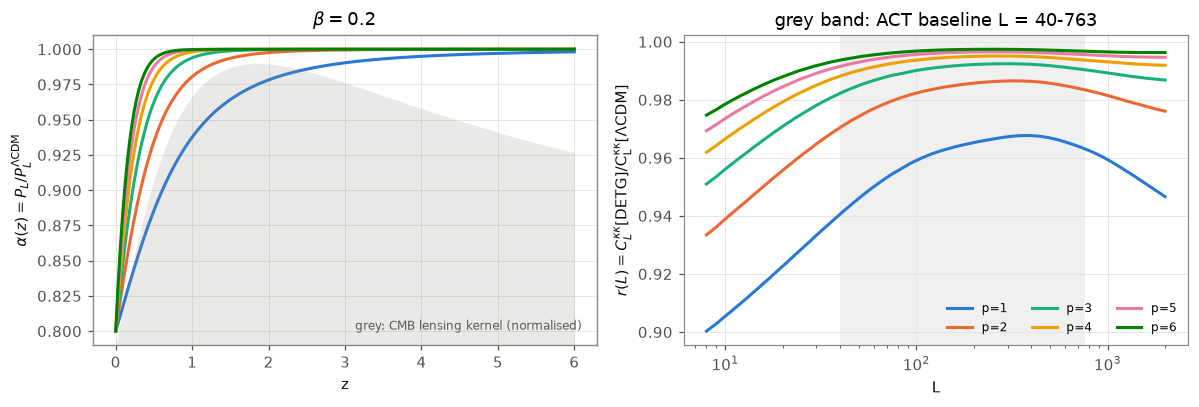

ACT baseline 範圍內的平均抑制 1-<r>： {1: 0.0355, 2: 0.0153, 3: 0.0087, 4: 0.0057, 5: 0.004, 6: 0.003}


In [11]:
BETA_SHOW = 0.2
pFID = to_As(dict(FID, beta_detg=BETA_SHOW))
zz = np.linspace(0, 6, 400)

# 用一個只含 lens-only DETG likelihood 的小 model 在 fiducial 點求值，取得 cobaya CAMB 的線性 P(k)
M_pk = make_model({"b0": (ACTDR6LensDETG, dict(variant="act_baseline", lens_only=True, growth_model="detg",
                                                **DETG_OPTS, **TRIM_OPT))})
evaluate(M_pk, dict(FID, beta_detg=BETA_SHOW))
PK_FID = get_pk_interp(M_pk)

st0, _, _ = CCLState.build_ccl(pFID, PK_FID, growth_model="none", mass_split=MASS_SPLIT)
trk = ccl.CMBLensingTracer(st0.base, z_source=1089.9)
chi = ccl.comoving_radial_distance(st0.base, 1/(1+zz))
wk = np.atleast_2d(trk.get_kernel(chi))[0]/ccl.h_over_h0(st0.base, 1/(1+zz))   # W_kappa(z) ∝ W(chi) dchi/dz
wk = wk/wk.max()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
R_SHOW = {}
for i, p in enumerate(range(1, 7)):
    gm = GrowthModel("detg", st0.omega_m, par=BETA_SHOW, p=p)
    ax[0].plot(zz, gm.alpha(1/(1+zz)), color=COLORS[i], label=f"p={p}")
    st, k_arr, a_nl = CCLState.build_ccl(pFID, PK_FID, growth_model="detg", p_detg=p, mass_split=MASS_SPLIT)
    R_SHOW[p] = CCLState.kk_transfer_ratio(st, k_arr, a_nl, lmax=2000)
    ax[1].plot(np.arange(2001)[8:], R_SHOW[p][8:], color=COLORS[i], label=f"p={p}")
ax0b = ax[0].twinx(); ax0b.fill_between(zz, 0, wk, color="#8a8984", alpha=0.18, lw=0)
ax0b.set_yticks([]); ax0b.grid(False); ax0b.set_ylim(0, wk.max()*1.1)
ax[0].text(0.97, 0.05, "grey: CMB lensing kernel (normalised)", color="#52514e", fontsize=8,
           ha="right", transform=ax[0].transAxes)
ax[0].set(xlabel="z", ylabel=r"$\alpha(z)=P_L/P_L^{\Lambda\rm CDM}$", title=rf"$\beta={BETA_SHOW}$")
ax[1].axvspan(40, 763, color="#8a8984", alpha=0.12, lw=0)
ax[1].set(xscale="log", xlabel="L", ylabel=r"$r(L)=C_L^{\kappa\kappa}[\rm DETG]/C_L^{\kappa\kappa}[\Lambda\rm CDM]$",
          title="grey band: ACT baseline L = 40-763")
ax[1].legend(ncol=3, fontsize=8); fig.tight_layout(); plt.show()

print("ACT baseline 範圍內的平均抑制 1-<r>：",
      {p: round(float(1 - R_SHOW[p][40:764].mean()), 4) for p in R_SHOW})

'''
左圖: 成長抑制 α(z) = P_L / P_L^LCDM 隨 z 變化 (DETG 下線性功率譜相對於 ΛCDM 的比例)
右圖: C_L^kk 抑制 r(L) = C_L^kk[DETG] / C_L^kk[LCDM] 隨 L 變化 (L:40-763 為 ACT baseline 的範圍)

β=0.2 
gray region (left): CMB lensing kernel W_kappa(z) (normalised)
gray region (right): ACT baseline 的 L 範圍 (40-763)
'''

### B2. Fisher matrix

$$F_{ij}=\frac{\partial \mathbf{t}}{\partial\theta_i}^{\!T}\,\mathbf{C}^{-1}\,\frac{\partial \mathbf{t}}{\partial\theta_j}+F^{\rm prior}_{ij}$$

- $\mathbf{t}$：`generic_lnlike` 實際使用的 binned theory vector（含所有修正），$\mathbf{C}^{-1}$：likelihood 裡的 `cinv`（已含 Hartlap）。
- 參數：$\{\omega_b,\omega_c,H_0,n_s,\ln10^{10}A_s,\beta\}$；`p` 固定，對 `P_LIST` 每個 p 各算一次（同一個 model 內放多個 likelihood，共用 CAMB）。
- 導數用中央差分，並用兩種步長（$h$、$h/2$）檢查導數穩定性。
- Gaussian prior：`GAUSS_PRIORS`。`FLAT_AS_GAUSS=True` 時，flat prior 以同寬度的 Gaussian（$\sigma=\text{寬度}/\sqrt{12}$）近似加入。CMB lensing 單獨幾乎只量到一個振幅組合，$H_0$–$\omega_c$ 等方向在 Fisher 裡是平的；不加這項，marginalized 誤差會發散成沒有意義的數字。
- Derived：$\sigma_8^{\rm DETG}=\sigma_8^{\Lambda\rm CDM}\sqrt{1-\beta}$（因為 $\alpha(z{=}0)=1-\beta$），並給出 $S_8=\sigma_8(\Omega_m/0.3)^{0.5}$ 與 lensing 實際量到的 $S_8^{\rm CMBL}=\sigma_8(\Omega_m/0.3)^{0.25}$。real 模式下，$\beta$ 固定時的 $\sigma(S_8^{\rm CMBL})$ 應接近 ACT DR6 lensing-only 發表值（約 0.02），可當作 Fisher 本身的 sanity check。

In [12]:
PARS  = ["ombh2", "omch2", "H0", "ns", "logA", "beta_detg"]
LATEX = {"ombh2": r"$\omega_b$", "omch2": r"$\omega_c$", "H0": r"$H_0$", "ns": r"$n_s$",
         "logA": r"$\ln10^{10}A_s$", "beta_detg": r"$\beta$"}
STEPS = {"ombh2": 4e-4, "omch2": 3e-3, "H0": 1.0, "ns": 0.01, "logA": 0.02, "beta_detg": 0.03}

fopts = dict(variant=FISHER_VARIANT, lens_only=True, ddir=DDIR_USED, growth_model="detg", **TRIM_OPT)
MF = make_model({f"p{p}": (ACTDR6LensDETG, dict(fopts, p_detg=float(p))) for p in P_LIST})
CINV = MF.likelihood[f"p{P_LIST[0]}"].data["cinv"]
DATA_VEC = MF.likelihood[f"p{P_LIST[0]}"].data["data_binned_clkk"]

DERIVED = ["sigma8_DETG", "S8_DETG", "S8CMBL_DETG"]
def derived_vec(der, beta):
    s8 = der["sigma8"]*np.sqrt(max(1 - beta, 0.0))
    return np.array([s8, s8*(der["omegam"]/0.3)**0.5, s8*(der["omegam"]/0.3)**0.25])

def theory(point):
    ll, caps, der = evaluate(MF, point)
    return {p: caps[f"p{p}"]["binned"] for p in P_LIST}, derived_vec(der, point["beta_detg"]), ll

THETA0 = dict(FID, beta_detg=BETA_FID)
t0 = time.time(); T0, D0, LL0 = theory(THETA0); t_eval = time.time() - t0
print(f"一次求值 {t_eval:.1f}s；Fisher 需要 {4*len(PARS)} 次，約 {4*len(PARS)*t_eval/60:.1f} 分鐘")
print("ACT S/N（fiducial theory）=", round(float(np.sqrt(T0[P_LIST[0]] @ CINV @ T0[P_LIST[0]])), 1))

INFO:camb:`camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


[camb] `camb` module loaded successfully from /home/andromeda/miniforge3/envs/cosmo/lib/python3.12/site-packages/camb


INFO:p1:ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


Loading ACT DR6 lensing likelihood v1.2...
[p1] ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


INFO:p3:ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


Loading ACT DR6 lensing likelihood v1.2...
[p3] ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


INFO:p5:ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON


Loading ACT DR6 lensing likelihood v1.2...
[p5] ACT DR6 lensing: variant=act_baseline lens_only=True like_corrections=False growth_ratio=ON
一次求值 1.7s；Fisher 需要 24 次，約 0.7 分鐘
ACT S/N（fiducial theory）= 39.1


In [13]:
def derivatives(scale):
    J = {p: np.zeros((T0[p].size, len(PARS))) for p in P_LIST}
    gD = np.zeros((len(DERIVED), len(PARS)))
    for j, par in enumerate(PARS):
        h = STEPS[par]*scale
        up, dn = dict(THETA0), dict(THETA0)
        up[par] += h; dn[par] -= h
        Tu, Su, _ = theory(up); Td, Sd, _ = theory(dn)
        for p in P_LIST:
            J[p][:, j] = (Tu[p] - Td[p])/(2*h)
        gD[:, j] = (Su - Sd)/(2*h)
    return J, gD

t0 = time.time()
J1, G1 = derivatives(1.0)
J2, G2 = derivatives(0.5)
print(f"derivatives done ({(time.time()-t0)/60:.1f} min)")

stab = pd.DataFrame({par: [float(np.max(np.abs(J1[p][:, j] - J2[p][:, j]))/max(np.max(np.abs(J2[p][:, j])), 1e-300))
                           for p in P_LIST] for j, par in enumerate(PARS)}, index=[f"p={p}" for p in P_LIST])
print("導數穩定性：max|dT(h) - dT(h/2)| / max|dT(h/2)|（< 1e-2 為佳）")
stab.style.format("{:.1e}")

derivatives done (0.6 min)
導數穩定性：max|dT(h) - dT(h/2)| / max|dT(h/2)|（< 1e-2 為佳）


,ombh2,omch2,H0,ns,logA,beta_detg
p=1,9.6e-03,1.4e-03,9.0e-05,4.3e-05,4.4e-05,1.7e-04
p=3,9.6e-03,1.4e-03,9.0e-05,4.3e-05,4.4e-05,2.0e-06
p=5,9.6e-03,1.4e-03,9.0e-05,4.3e-05,4.4e-05,3.1e-06


In [14]:
def prior_sigma(par):
    if par in GAUSS_PRIORS: return GAUSS_PRIORS[par]
    if FLAT_AS_GAUSS and par in FLAT_PRIORS:
        lo, hi = FLAT_PRIORS[par]; return (hi - lo)/np.sqrt(12)
    return np.inf

def prior_fisher(pars):
    return np.diag([1/prior_sigma(par)**2 for par in pars])

def fisher(J, pars_idx=None):
    idx = list(range(len(PARS))) if pars_idx is None else pars_idx
    Jx = J[:, idx]
    return Jx.T @ CINV @ Jx + prior_fisher([PARS[i] for i in idx])

FISH, COV = {}, {}
rows = []
for p in P_LIST:
    F = fisher(J2[p]); C = np.linalg.inv(F)
    FISH[p], COV[p] = F, C
    ib = PARS.index("beta_detg")
    sig = np.sqrt(np.diag(C)); cond = 1/np.sqrt(np.diag(F))
    # beta 固定（LCDM）時的 S8 誤差 vs beta 自由
    idx_l = [i for i in range(len(PARS)) if i != ib]
    C_l = np.linalg.inv(fisher(J2[p], idx_l))
    for i, par in enumerate(PARS):
        rows.append(dict(p=p, param=par, fid=THETA0[par], sigma_marg=sig[i], sigma_cond=cond[i],
                         degeneracy=sig[i]/cond[i], sigma_prior=prior_sigma(par),
                         rho_with_beta=C[i, ib]/np.sqrt(C[i, i]*C[ib, ib])))
    for d, dname in enumerate(DERIVED):
        g = G2[d]
        s_free = float(np.sqrt(g @ C @ g)); s_fix = float(np.sqrt(g[idx_l] @ C_l @ g[idx_l]))
        rows.append(dict(p=p, param=f"{dname} (beta free)", fid=D0[d], sigma_marg=s_free, sigma_cond=np.nan,
                         degeneracy=np.nan, sigma_prior=np.nan, rho_with_beta=float((g @ C[:, ib])/np.sqrt(s_free**2*C[ib, ib]))))
        rows.append(dict(p=p, param=f"{dname} (beta fixed)", fid=D0[d], sigma_marg=s_fix, sigma_cond=np.nan,
                         degeneracy=np.nan, sigma_prior=np.nan, rho_with_beta=np.nan))
dfF = pd.DataFrame(rows)
print("sigma_marg：其他參數 marginalize 後的 1σ；sigma_cond：其他參數固定時的 1σ；degeneracy = 兩者比值；"
      "sigma_prior：prior 本身的寬度（sigma_marg 接近它 → 該參數由 prior 決定）")

# 資料實際約束了幾個方向：prior-whitened 的 data Fisher 特徵值 > 1 的個數
sp = np.array([prior_sigma(par) if np.isfinite(prior_sigma(par)) else 1.0 for par in PARS])
for p in P_LIST:
    Fd = J2[p].T @ CINV @ J2[p]
    lam = np.linalg.eigvalsh(Fd*np.outer(sp, sp))[::-1]
    print(f"p={p}: prior-whitened data-Fisher eigenvalues = {np.array2string(lam, precision=2)}"
          f"  → 資料比 prior 強的方向：{int((lam > 1).sum())} / {len(PARS)}")
dfF.round(5)

sigma_marg：其他參數 marginalize 後的 1σ；sigma_cond：其他參數固定時的 1σ；degeneracy = 兩者比值；sigma_prior：prior 本身的寬度（sigma_marg 接近它 → 該參數由 prior 決定）
p=1: prior-whitened data-Fisher eigenvalues = [1.74e+04 3.87e+01 1.27e-01 4.40e-03 2.59e-04 6.97e-08]  → 資料比 prior 強的方向：2 / 6
p=3: prior-whitened data-Fisher eigenvalues = [1.74e+04 3.59e+01 3.21e-02 3.73e-03 2.59e-04 1.76e-07]  → 資料比 prior 強的方向：2 / 6
p=5: prior-whitened data-Fisher eigenvalues = [1.74e+04 3.57e+01 1.38e-02 2.41e-03 2.58e-04 2.43e-07]  → 資料比 prior 強的方向：2 / 6


,p,param,fid,sigma_marg,sigma_cond,degeneracy,sigma_prior,rho_with_beta
0,1,ombh2,0.02237,0.00050,0.00049,1.01611,0.00050,0.00309
1,1,omch2,0.12000,0.01235,0.00219,5.63990,0.28435,-0.42018
2,1,H0,67.36000,17.15851,3.19765,5.36597,17.32051,-0.05061
3,1,ns,0.96490,0.01991,0.01753,1.13566,0.02000,-0.01555
4,1,logA,3.04400,0.19285,0.02494,7.73202,0.57735,0.76059
5,1,beta_detg,0.00000,0.52366,0.12988,4.03186,0.57735,1.00000
6,1,sigma8_DETG (beta free),0.81106,0.20405,NaN,NaN,NaN,-0.87097
7,1,sigma8_DETG (beta fixed),0.81106,0.10025,NaN,NaN,NaN,NaN
8,1,S8_DETG (beta free),0.83135,0.20958,NaN,NaN,NaN,-0.89001
9,1,S8_DETG (beta fixed),0.83135,0.09556,NaN,NaN,NaN,NaN


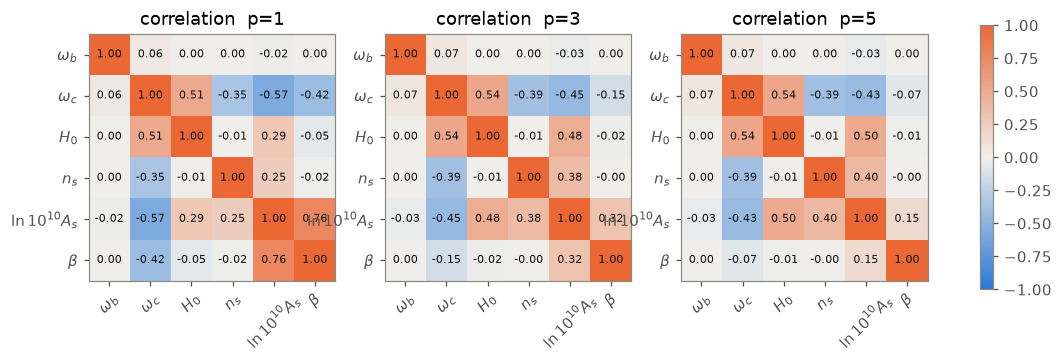

In [ ]:
# 相關係數矩陣（每個 p 一張）
fig, axs = plt.subplots(1, len(P_LIST), figsize=(4.1*len(P_LIST), 3.9))
axs = np.atleast_1d(axs)
for a, p in zip(axs, P_LIST):
    C = COV[p]; rho = C/np.sqrt(np.outer(np.diag(C), np.diag(C)))
    im = a.imshow(rho, cmap=DIVERGING, vmin=-1, vmax=1)
    a.set_xticks(range(len(PARS)), [LATEX[x] for x in PARS], rotation=45)
    a.set_yticks(range(len(PARS)), [LATEX[x] for x in PARS]); a.grid(False)
    for i in range(len(PARS)):
        for j in range(len(PARS)):
            a.text(j, i, f"{rho[i, j]:.2f}", ha="center", va="center", fontsize=7, color="#0b0b0b")
    a.set_title(f"correlation  p={p}")
fig.colorbar(im, ax=axs, shrink=0.8); plt.show()

'''p=1 時 ρ(β, A_s) ≈ 0.76：β 變大會壓低成長，A_s 調高就能補回來'''

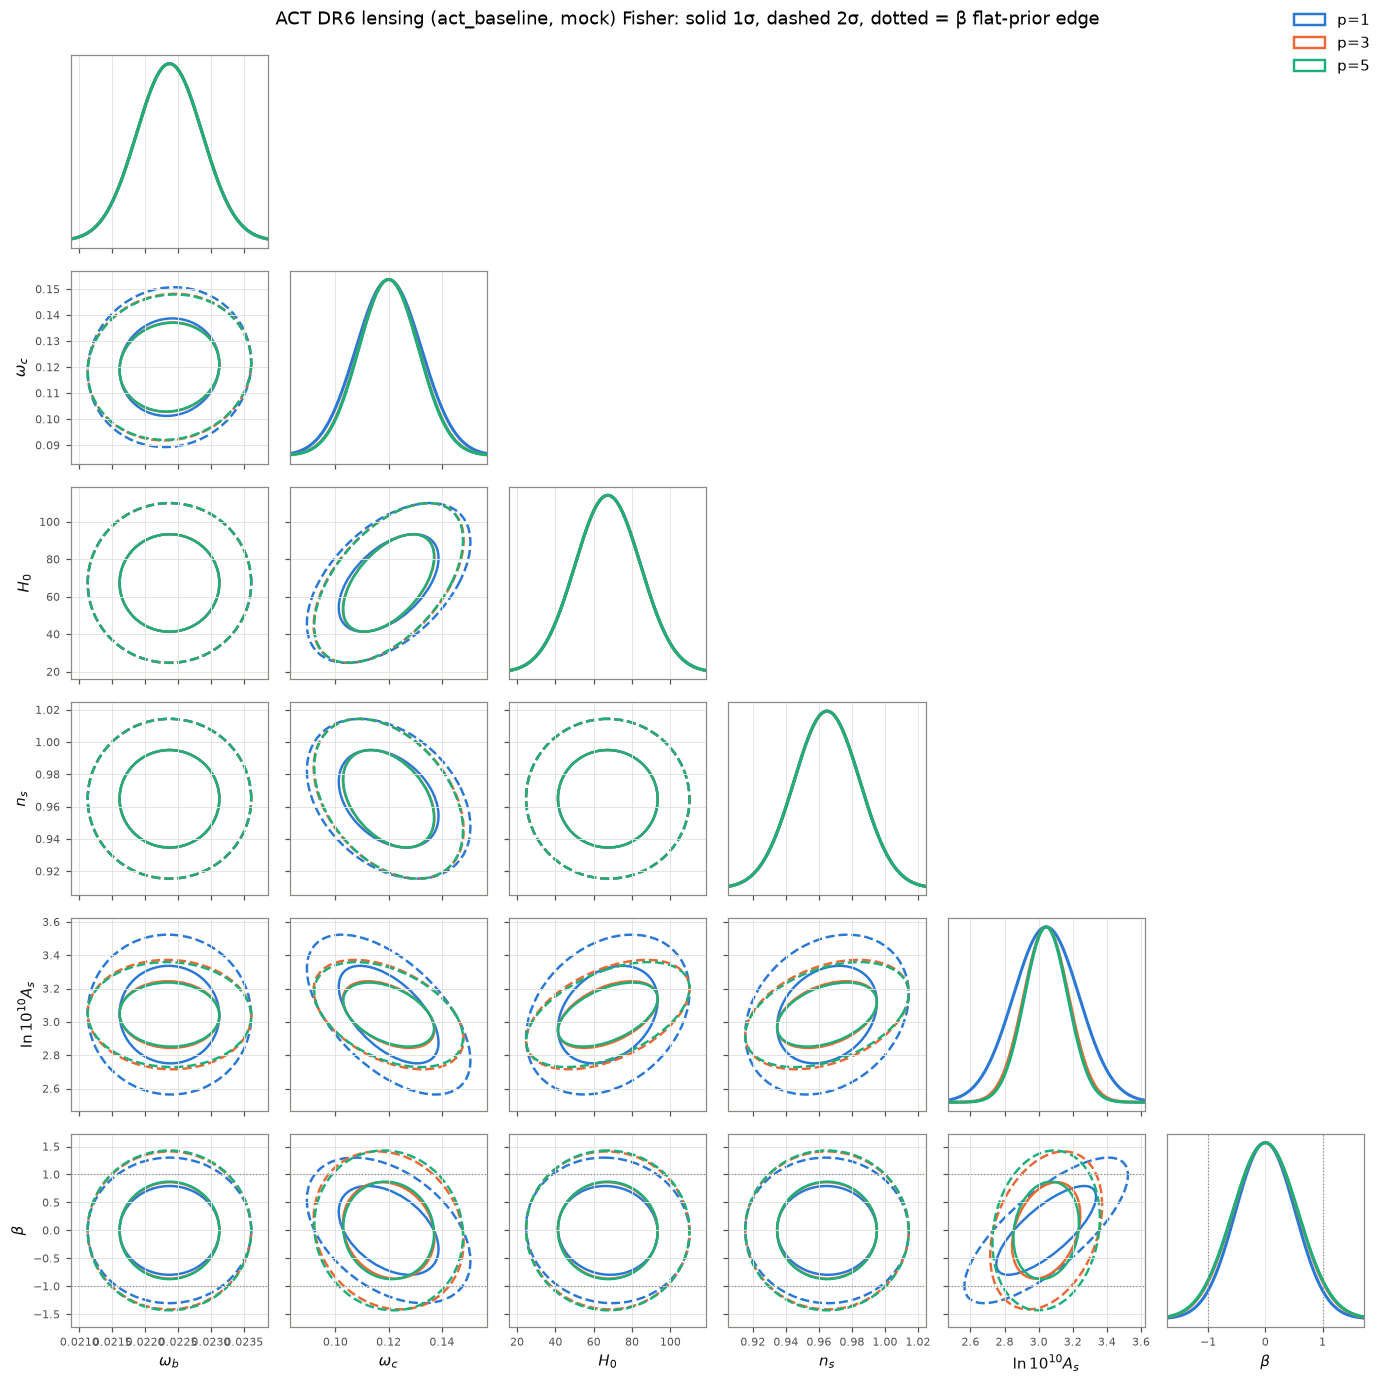

In [ ]:
from matplotlib.patches import Ellipse

# Fisher 橢圓（1σ、2σ；Δχ²=2.30, 6.18）
def ellipse(ax, C2, mu, color, label=None):
    w, v = np.linalg.eigh(C2)
    ang = np.degrees(np.arctan2(v[1, 1], v[0, 1]))
    for k, ls in [(2.30, "-"), (6.18, "--")]:
        ax.add_patch(Ellipse(mu, 2*np.sqrt(k*w[1]), 2*np.sqrt(k*w[0]), angle=ang, fill=False,
                             ec=color, lw=1.6, ls=ls, label=label if ls == "-" else None))

n = len(PARS)
fig, axs = plt.subplots(n, n, figsize=(2.1*n, 2.1*n))
for i in range(n):
    for j in range(n):
        a = axs[i, j]
        if j > i:
            a.axis("off"); continue
        smax = max(np.sqrt(COV[p][j, j]) for p in P_LIST)
        a.set_xlim(THETA0[PARS[j]] - 3*smax, THETA0[PARS[j]] + 3*smax)
        if i == j:
            x = np.linspace(*a.get_xlim(), 300)
            for k, p in enumerate(P_LIST):
                s = np.sqrt(COV[p][i, i]); a.plot(x, np.exp(-0.5*((x - THETA0[PARS[i]])/s)**2), color=COLORS[k])
            a.set_yticks([])
        else:
            smy = max(np.sqrt(COV[p][i, i]) for p in P_LIST)
            a.set_ylim(THETA0[PARS[i]] - 3*smy, THETA0[PARS[i]] + 3*smy)
            for k, p in enumerate(P_LIST):
                ellipse(a, COV[p][np.ix_([j, i], [j, i])], (THETA0[PARS[j]], THETA0[PARS[i]]), COLORS[k],
                        label=f"p={p}")
        if PARS[j] == "beta_detg" or PARS[i] == "beta_detg":
            for lim in FLAT_PRIORS["beta_detg"]:
                (a.axvline if PARS[j] == "beta_detg" else a.axhline)(lim, color="#8a8984", lw=0.8, ls=":")
        if i == n - 1: a.set_xlabel(LATEX[PARS[j]])
        else: a.set_xticklabels([])
        if j == 0 and i > 0: a.set_ylabel(LATEX[PARS[i]])
        elif j > 0: a.set_yticklabels([])
        a.tick_params(labelsize=7)
h, l = axs[1, 0].get_legend_handles_labels()
fig.legend(h, l, loc="upper right", fontsize=10)
fig.suptitle(f"ACT DR6 lensing ({FISHER_VARIANT}, {DATA_MODE}) Fisher: solid 1σ, dashed 2σ, dotted = β flat-prior edge", y=0.995)
fig.tight_layout(); plt.show()

'''
排列：下三角格狀。第 i 列、第 j 欄的子圖，x 軸是參數 j，y 軸是參數 i；最下面一列標出 x 軸名稱，最左邊一欄標出 y 軸名稱。
非對角子圖：兩個參數的 2D Fisher 等高線，中心在 fiducial 值。實線是 1σ（68%，Δχ² = 2.30），虛線是 2σ（95%，Δχ² = 6.18）。顏色代表不同的 p。
對角子圖：x 軸是該參數，y 軸是 1D Gaussian 的相對機率，峰值歸一成 1，沒有單位。
灰色點線：β = ±1，也就是 β 的 flat prior 邊界。
軸範圍：fiducial ± 3σ，σ 取三個 p 裡最大的那個。
怎麼讀：
橢圓傾斜表示兩個參數相關，越扁表示簡併越強；
橢圓超出點線，表示 posterior 會被 prior 截斷，Fisher 的高斯近似在那裡不成立；
ω_b、n_s、H₀ 的橢圓大小基本上就是 prior 的寬度，表示 lensing 量不到這些參數。
'''

### B3. 參數效應：每個參數變動 $1\sigma_{\rm marg}$ 時，bandpower 改變多少個誤差棒

$\Delta t_b/\sigma_b$，其中 $\sigma_b=\sqrt{C_{bb}}$。曲線形狀相似（只差比例）就代表兩個參數在這筆資料中難以區分，也就是簡併的來源。

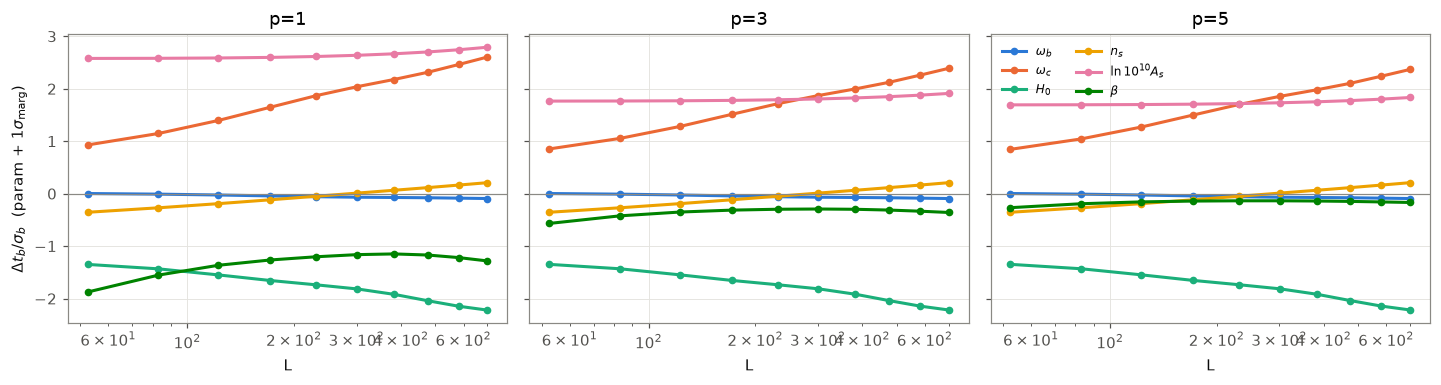

p=1: |cos|(beta, logA)=0.9844   |cos|(beta, omch2)=0.9121
p=3: |cos|(beta, logA)=0.9730   |cos|(beta, omch2)=0.8951
p=5: |cos|(beta, logA)=0.9723   |cos|(beta, omch2)=0.8964


In [ ]:
SIGMA_B = np.sqrt(np.diag(np.linalg.inv(CINV)))
bc = MF.likelihood[f"p{P_LIST[0]}"].data["bcents_act"]
nb_act = bc.size
fig, axs = plt.subplots(1, len(P_LIST), figsize=(4.4*len(P_LIST), 3.6), sharey=True)
axs = np.atleast_1d(axs)
for a, p in zip(axs, P_LIST):
    for k, par in enumerate(PARS):
        resp = J2[p][:nb_act, k]*np.sqrt(COV[p][k, k])/SIGMA_B[:nb_act]
        a.plot(bc, resp, color=COLORS[k], marker="o", ms=4, label=LATEX[par])
    a.axhline(0, color="#8a8984", lw=0.8); a.set(xscale="log", xlabel="L", title=f"p={p}")
axs[0].set_ylabel(r"$\Delta t_b/\sigma_b$  (param + 1$\sigma_{\rm marg}$)")
axs[-1].legend(fontsize=8, ncol=2); fig.tight_layout(); plt.show()

# 形狀相似度：把 response 歸一後取 cos 相似度（|cos|→1 表示完全簡併）
for p in P_LIST:
    W = J2[p][:nb_act]/SIGMA_B[:nb_act, None]
    Wn = W/np.linalg.norm(W, axis=0)
    cs = Wn.T @ Wn
    print(f"p={p}: |cos|(beta, logA)={abs(cs[PARS.index('beta_detg'), PARS.index('logA')]):.4f}   "
          f"|cos|(beta, omch2)={abs(cs[PARS.index('beta_detg'), PARS.index('omch2')]):.4f}")

'''
x 軸：ACT bandpower 的中心 L，對數刻度。baseline 大約有 10 個 bin，涵蓋 40–763。
y 軸：Δt_b / σ_b。把某個參數往上調 1σ_marg 之後，第 b 個 bin 的 binned C_L^κκ 改變量，除以這個 bin 的誤差棒（共變異矩陣對角項開根號）。
曲線：每條線代表一個參數。
怎麼讀：
數值大小代表這個參數改變時，資料會偏離幾個誤差棒；
兩條曲線形狀相同（只差一個比例），就代表資料分不開這兩個參數。
β 的線是負的，因為 β>0 會壓低 C_L^κκ。
圖下印的數字：β 和 A_s、β 和 ω_c 的形狀相似度 |cos|，越接近 1 越簡併。你的結果是 0.97–0.98。
'''

### B4. Fisher 是否可信：exact $\Delta\chi^2$ vs Fisher

在 $\beta\in\{-0.8,-0.4,0.4,0.8\}$（都在 prior 內、物理上允許）用完整 pipeline 重算 exact $\Delta\chi^2$（以 fiducial theory 當資料，即 Asimov），與 Fisher 預測比較。三種方向：

| 方向 | 其他參數 | Fisher 預測 |
|---|---|---|
| (a) conditional | 全部固定 | $F_{\beta\beta}\Delta\beta^2$ |
| (b) $\beta$–$A_s$ | 只讓 $\ln10^{10}A_s$ 依 Fisher 最佳化跟著調 | $(F_{\beta\beta}-F_{\beta A}^2/F_{AA})\Delta\beta^2$ |
| (c) full profile | 全部依 Fisher 最佳化跟著調：$\Delta\boldsymbol\theta=\mathbf{C}_{:,\beta}\Delta\beta/C_{\beta\beta}$ | $\Delta\beta^2/C_{\beta\beta}$ |

- (a)(b) 的 $\Delta\chi^2_{\rm exact}/\Delta\chi^2_{\rm Fisher}$ 偏離 1 超過 20% → $\beta$ 的效應非線性，Fisher 不可信。
- (c) 需要其他參數移到 flat prior 外（例如 $H_0$、$\omega_c$），才能吸收 $\beta$ → posterior 會被 prior 邊界截斷，Fisher 不能代替 MCMC。

（只計資料項；Gaussian prior 項在 (c) 另外加上。）

In [22]:
BETA_GRID = [-0.8, -0.4, 0.4, 0.8]
CHECK = []

def chi2_data(p, point):
    T, _, _ = theory(point)
    d = T[p] - T0[p]
    return float(d @ CINV @ d)

def out_of_bounds(point):
    return [k for k, (lo, hi) in FLAT_PRIORS.items() if not (lo <= point[k] <= hi)]

t0 = time.time()
ib, iA = PARS.index("beta_detg"), PARS.index("logA")
for p in P_LIST:
    Fd = J2[p].T @ CINV @ J2[p]                 # 只有資料項
    F, C = FISH[p], COV[p]
    for b in BETA_GRID:
        db = b - THETA0["beta_detg"]
        # (a) conditional
        pa = dict(THETA0); pa["beta_detg"] = b
        # (b) beta–As：logA 依「資料 Fisher」最佳化
        pb = dict(pa); pb["logA"] = THETA0["logA"] - Fd[iA, ib]/Fd[iA, iA]*db
        # (c) full profile（含 prior 的 Fisher）
        pc = {par: THETA0[par] + C[i, ib]/C[ib, ib]*db for i, par in enumerate(PARS)}
        prior_c = float(sum(((pc[k] - THETA0[k])/prior_sigma(k))**2 for k in PARS
                            if np.isfinite(prior_sigma(k)) and k != "beta_detg"))
        for name, pt, fis, extra in [("a conditional", pa, Fd[ib, ib]*db**2, 0.0),
                                     ("b beta-As", pb, (Fd[ib, ib] - Fd[ib, iA]**2/Fd[iA, iA])*db**2, 0.0),
                                     ("c full profile", pc, db**2/C[ib, ib] - db**2/prior_sigma("beta_detg")**2, prior_c)]:
            bad = out_of_bounds(pt)
            ex = chi2_data(p, pt) + extra
            CHECK.append(dict(p=p, direction=name, beta=b, fisher=fis, exact=ex, ratio=ex/fis if fis > 0 else np.nan,
                              logA=pt["logA"], H0=pt["H0"], omch2=pt["omch2"], out_of_prior=",".join(bad)))
print(f"done ({(time.time()-t0)/60:.1f} min)")
dfG = pd.DataFrame(CHECK); dfG.round(4)

done (0.9 min)


,p,direction,beta,fisher,exact,ratio,logA,H0,omch2,out_of_prior
0,1,a conditional,-0.8,36.0190,37.7139,1.0471,3.0440,67.3600,0.1200,
1,1,b beta-As,-0.8,1.1814,0.9649,0.8168,2.8966,67.3600,0.1200,
2,1,c full profile,-0.8,0.4139,0.4893,1.1824,2.8199,68.6865,0.1279,
3,1,a conditional,-0.4,9.0047,9.2304,1.0251,3.0440,67.3600,0.1200,
4,1,b beta-As,-0.4,0.2953,0.2564,0.8682,2.9703,67.3600,0.1200,
5,1,c full profile,-0.4,0.1035,0.1010,0.9760,2.9320,68.0233,0.1240,
6,1,a conditional,0.4,9.0047,8.7448,0.9711,3.0440,67.3600,0.1200,
7,1,b beta-As,0.4,0.2953,0.3619,1.2254,3.1177,67.3600,0.1200,
8,1,c full profile,0.4,0.1035,0.1312,1.2685,3.1560,66.6967,0.1160,
9,1,a conditional,0.8,36.0190,33.7604,0.9373,3.0440,67.3600,0.1200,


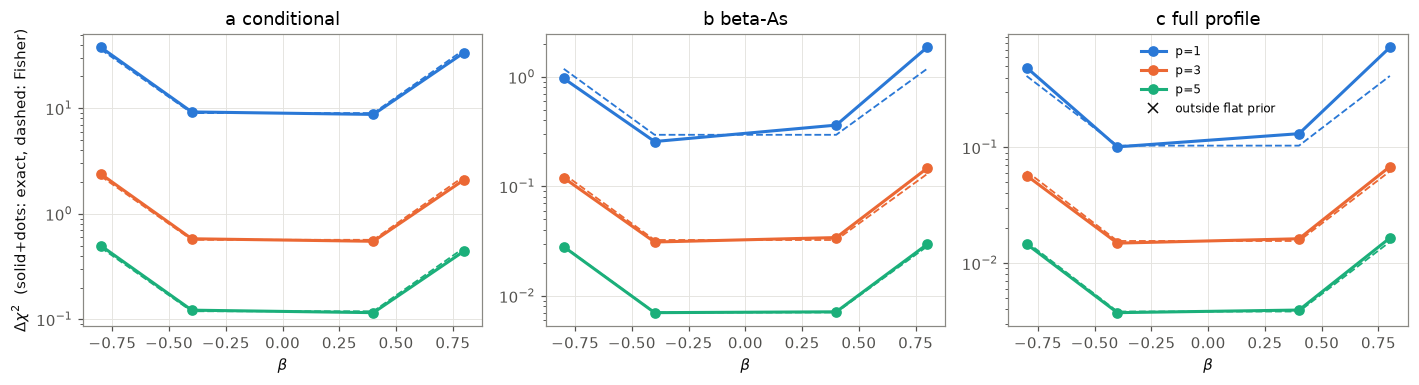

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
for a, dname in zip(axs, ["a conditional", "b beta-As", "c full profile"]):
    for k, p in enumerate(P_LIST):
        s_ = dfG[(dfG.p == p) & (dfG.direction == dname)]
        a.plot(s_.beta, s_.fisher, "--", color=COLORS[k], lw=1.2)
        a.plot(s_.beta, s_.exact, "o-", color=COLORS[k], ms=6, label=f"p={p}")
        off = s_[s_.out_of_prior != ""]
        a.plot(off.beta, off.exact, "x", color="#0b0b0b", ms=9, mew=1.5)
    a.set(xlabel=r"$\beta$", title=dname, yscale="log")
axs[0].set_ylabel(r"$\Delta\chi^2$  (solid+dots: exact, dashed: Fisher)")
axs[2].plot([], [], "x", color="#0b0b0b", label="outside flat prior")
axs[2].legend(fontsize=8); fig.tight_layout(); plt.show()

'''
x 軸：β 的值，只畫了 −0.8、−0.4、0.4、0.8 四個點 β=0 時 Δχ²=0，沒有畫
y 軸：Δχ²（相對於 fiducial），對數刻度。
線：實線加圓點是 exact，同色虛線是 Fisher 預測。× 表示該點超出 flat prior

實線和虛線重疊，表示 Fisher 可信
'''

### B5.（選用）加入 HSC Fisher

ACT 單獨能約束的只有一個振幅組合，$\beta$ 主要要靠 HSC（低紅移）和 CMB lensing（高紅移）的紅移差異來分開。把已通過驗證的 HSC likelihood，用下面的 `fisher_from_theory` 對同樣的 `PARS`、同樣的 fiducial 與 p 算出 Fisher（HSC 的 nuisance 參數請先 marginalize：對 HSC 完整 Fisher 求逆、取 `PARS` 的子矩陣、再求逆），存成 `npz`（`F`、`params`；多個 p 時用 `F_p1`、`F_p3`…），指定 `HSC_FISHER_FILE` 後重跑本節與 C 節。

In [28]:
def fisher_from_theory(theory_fn, cinv, theta0, pars, steps, scale=0.5):
    """通用 Fisher：theory_fn(point) -> 資料向量。HSC 可直接沿用。"""
    t0 = theory_fn(theta0); J = np.zeros((t0.size, len(pars)))
    for j, par in enumerate(pars):
        h = steps[par]*scale; up, dn = dict(theta0), dict(theta0)
        up[par] += h; dn[par] -= h
        J[:, j] = (theory_fn(up) - theory_fn(dn))/(2*h)
    return J.T @ cinv @ J

FISH_JOINT = {}
if HSC_FISHER_FILE and os.path.exists(HSC_FISHER_FILE):
    z = np.load(HSC_FISHER_FILE, allow_pickle=True)
    hp = [str(x) for x in z["params"]]
    for p in P_LIST:
        Fh_in = z[f"F_p{p}"] if f"F_p{p}" in z else z["F"]
        Fh = np.zeros((len(PARS), len(PARS)))
        for i, a_ in enumerate(PARS):
            for j, b_ in enumerate(PARS):
                if a_ in hp and b_ in hp:
                    Fh[i, j] = Fh_in[hp.index(a_), hp.index(b_)]
        # 注意：Gaussian / flat-approx prior 已在 FISH[p] 裡，HSC Fisher 不要再含同樣的 prior
        FISH_JOINT[p] = FISH[p] + Fh
    rowsJ = []
    for p in P_LIST:
        Cj = np.linalg.inv(FISH_JOINT[p]); ib = PARS.index("beta_detg")
        rowsJ.append(dict(p=p, sigma_beta_ACT=np.sqrt(COV[p][ib, ib]), sigma_beta_ACTxHSC=np.sqrt(Cj[ib, ib]),
                          rho_beta_logA_joint=Cj[ib, PARS.index("logA")]/np.sqrt(Cj[ib, ib]*Cj[PARS.index("logA"), PARS.index("logA")])))
    display(pd.DataFrame(rowsJ))
else:
    print("未提供 HSC Fisher；C 節只根據 ACT 單獨的結果判斷。")

未提供 HSC Fisher；C 節只根據 ACT 單獨的結果判斷。


## C. 結論：是否需要 MCMC

對每個 p 自動判斷下列條件（門檻可在下方調整）：

| 判準 | 意義 | 門檻 |
|---|---|---|
| prior-dominated | $\sigma_\beta$ 與 flat prior 的標準差（$2/\sqrt{12}=0.577$）相比；接近 1 表示這組資料對 $\beta$ 幾乎沒有資訊，單獨跑 MCMC 只會得到 prior | $\sigma_\beta/\sigma_{\rm prior}>0.5$ |
| 強簡併 | $\sigma_{\rm marg}/\sigma_{\rm cond}$；大表示 $\beta$ 的資訊主要被其他參數吸收 | $>3$ |
| 非 Gaussian | B4 (a)(b) 中 $|\Delta\chi^2_{\rm exact}/\Delta\chi^2_{\rm Fisher}-1|$ 的最大值 | $>0.2$ |
| 撞到邊界 | B4 (c) 的 profile 需要其他參數超出 flat prior；ACT+HSC 時改用 $\beta_0\pm2\sigma_\beta$ 是否碰到 $\pm1$ | 任何一點 |

- **非 Gaussian 或撞到邊界** → Fisher 不能代替 posterior，需要 MCMC。
- **prior-dominated** → 這組資料單獨跑 MCMC 意義不大；應該先加入 HSC（B5）再判斷。
- 全部不成立 → Fisher 已足以描述 posterior，MCMC 只是確認。

In [25]:
THR = dict(prior_dom=0.5, degeneracy=3.0, nongauss=0.2)
SIG_PRIOR_BETA = (FLAT_PRIORS["beta_detg"][1] - FLAT_PRIORS["beta_detg"][0])/np.sqrt(12)

def verdict(p, Fdict, label):
    C = np.linalg.inv(Fdict[p]); ib = PARS.index("beta_detg")
    sb = float(np.sqrt(C[ib, ib])); deg = sb*np.sqrt(Fdict[p][ib, ib])
    g = dfG[dfG.p == p]
    gab = g[g.direction.isin(["a conditional", "b beta-As"])]
    ng = float(np.nanmax(np.abs(gab.ratio - 1))) if label == "ACT" else np.nan
    hit = (bool((g[g.direction == "c full profile"].out_of_prior != "").any()) if label == "ACT"
           else bool(THETA0["beta_detg"] + 2*sb >= 1 or THETA0["beta_detg"] - 2*sb <= -1))
    pdom = sb/SIG_PRIOR_BETA > THR["prior_dom"]
    need = []
    if hit: need.append("撞到 prior 邊界")
    if np.isfinite(ng) and ng > THR["nongauss"]: need.append("非 Gaussian")
    if pdom:
        concl = "β 由 prior 主導：這組資料單獨跑 MCMC 意義不大，先加入 HSC 再判斷"
    elif need:
        concl = "需要 MCMC（" + "、".join(need) + "）"
    elif deg > THR["degeneracy"]:
        concl = "Fisher 尚可，但簡併強；建議 MCMC 確認"
    else:
        concl = "Fisher 足以描述 posterior；MCMC 僅作確認"
    return dict(data=label, p=p, sigma_beta=sb, sigma_beta_over_prior=sb/SIG_PRIOR_BETA,
                degeneracy=deg, rho_beta_logA=C[ib, PARS.index("logA")]/np.sqrt(C[ib, ib]*C[PARS.index("logA"), PARS.index("logA")]),
                max_nongauss=ng, hits_prior=hit, conclusion=concl)

# res = [verdict(p, FISH, "ACT") for p in P_LIST]
# if FISH_JOINT:
#     res += [verdict(p, FISH_JOINT, "ACT+HSC") for p in P_LIST]
# dfC = pd.DataFrame(res)
# pd.set_option("display.max_colwidth", 120)
# print(f"DATA_MODE = {DATA_MODE}" + ("   ⚠ mock 資料：數字只用來確認流程，不可當作結果" if DATA_MODE == "mock" else ""))
# dfC.round(4)

In [27]:
# 存檔，方便之後與 HSC / MCMC 結果比較
out = f"{WORK_DIR}/fisher_act_{DATA_MODE}.npz"
np.savez(out, params=np.array(PARS), theta0=np.array([THETA0[k] for k in PARS]),
         **{f"F_p{p}": FISH[p] for p in P_LIST}, **{f"J_p{p}": J2[p] for p in P_LIST}, cinv=CINV)
dfA1.to_csv(f"{WORK_DIR}/validation_A1_{DATA_MODE}.csv", index=False)
dfA2.to_csv(f"{WORK_DIR}/validation_A2_{DATA_MODE}.csv", index=False)
# dfC.to_csv(f"{WORK_DIR}/verdict_{DATA_MODE}.csv", index=False)
print("saved:", out)

saved: ./detg_validation_work/fisher_act_mock.npz
